In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Numerics: Dtypes and Mixed Precision

Every tensor carries three attributes: a shape, a device, and a *dtype*, the
numeric format of its entries. So far we have left the dtype at its default,
32-bit floating point, and nothing forced us to look at it. That grace period
is over. Modern accelerators multiply 16-bit matrices several times faster
than 32-bit ones, in half the memory, and essentially all serious training now
chooses numeric formats deliberately. This section covers what a builder needs:
which formats exist, what each one can and cannot represent, how dtypes combine,
and the standard recipe (*mixed precision*) for training in 16 bits without
giving up 32-bit accuracy. For the anatomy of a floating-point number (sign,
exponent, mantissa) see that section;
here we ask the practical questions: when does it break, and which switch do
I flip.

In [1]:
import jax
import time
from jax import numpy as jnp
from flax import nnx
import optax
from d2l import jax as d2l

## The Dtype Zoo

Half-precision (`float16`, "fp16") sounds like a free lunch: half the
bytes of fp32, and the format that accelerator hardware sped up first. Here
is the catch. The largest number fp16 can represent is 65504. Square a value
of 300, which is nothing exotic (an unnormalized logit, an intermediate in a
variance computation), and you have already left the representable range:

In [2]:
x = jnp.array(300.0)
x.astype(jnp.float16)**2, x.astype(jnp.bfloat16)**2

(Array(inf, dtype=float16), Array(90112, dtype=bfloat16))

fp16 overflows to `inf`. The second format, `bfloat16` ("bf16", brain
floating point), returns 90112: wrong in the fourth digit, since the exact
square is 90000, but finite. The two formats spend the same 16 bits
differently. fp16 uses 5 exponent bits and 10 mantissa bits: fine-grained
steps, tiny range. bf16 keeps fp32's full 8 exponent bits and pays with a
7-bit mantissa: fp32's range, coarse steps. The one-line demo above shows both
consequences at once.


| format | sign | exponent | mantissa |
|:-------|-----:|---------:|---------:|
| fp32   | 1    | 8        | 23       |
| tf32   | 1    | 8        | 10       |
| bf16   | 1    | 8        | 7        |
| fp16   | 1    | 5        | 10       |
| fp8 (e4m3) | 1 | 4       | 3        |

the figure draws the same table as bit layouts, aligned
at the sign bit so the total widths compare directly: fp32 spends its 32 bits
on a wide mantissa, while bf16 keeps fp32's 8-bit exponent but pays for it
with a narrow 7-bit mantissa, and fp16 inverts the trade.

![Bit layouts of the five formats in the table above, aligned at the sign bit so a wider bar means more total bits: fp32 is the widest, tf32 shares fp32's exponent but truncates the mantissa to 10 bits, and fp16 trades exponent bits for mantissa bits that bf16 spends the other way.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/bg-float-formats.svg)

`finfo` reports what each bit budget buys. Three numbers matter: `max`,
the overflow threshold; `tiny`, the smallest *normal* value, below which
subnormal values provide a short, progressively less precise tail before zero;
and `eps`, the relative step size between adjacent representable values near 1.

In [3]:
for dtype in (jnp.float32, jnp.bfloat16, jnp.float16):
    fi = jnp.finfo(dtype)
    print(f'{fi.dtype.name:10} max {float(fi.max):10.3e}'
          f'  tiny {float(fi.tiny):9.3e}  eps {float(fi.eps):8.3e}')

float32    max  3.403e+38  tiny 1.175e-38  eps 1.192e-07
bfloat16   max  3.390e+38  tiny 1.175e-38  eps 7.812e-03
float16    max  6.550e+04  tiny 6.104e-05  eps 9.766e-04


bf16 matches fp32's `tiny` and has nearly the same `max`: its shared exponent
width gives the same normal exponent range, while its shorter mantissa makes
the largest finite value slightly smaller. Its `eps` of 0.0078 means two to
three significant decimal digits. fp16 resolves about three to four digits,
overflows at 65504, enters the subnormal range below about
$6.10 \times 10^{-5}$, and reaches zero only below about
$5.96 \times 10^{-8}$. The trade is precision against range, and for deep
learning the choice is lopsided: activations and gradients span many orders
of magnitude, occasional large values are routine, and running out of range
produces `inf` while losing a low-order digit usually costs nothing a noisy
gradient estimate had to offer anyway. That asymmetry is why bf16 became the
default 16-bit format for training.

### TF32: What Happens to fp32 Matrix Multiplication

The second row of the table, tf32, is not a storage dtype; you cannot create a
tensor of it. It is a compute mode of NVIDIA tensor cores (Ampere generation
and later): matrix-multiply inputs are rounded to a 10-bit mantissa while
keeping fp32's exponent, and products are accumulated in fp32. Your tensors
stay fp32; only the arithmetic inside the multiplication runs faster and
slightly less precisely. Most of our frameworks expose a switch for it:

In [4]:
print(jax.config.jax_default_matmul_precision)
with jax.default_matmul_precision('tensorfloat32'):
    print(jax.config.jax_default_matmul_precision)

None
tensorfloat32


The unset config (`None`) means "let the backend pick", and on tensor-core
GPUs XLA's pick for fp32 matrix multiplications is the fast tf32 path: the
opposite polarity from PyTorch, which today makes you opt in. You opt *out*
by requesting `'float32'` (or `'highest'`), and the setting is a scoped
context manager rather than a global flag, so a numerically delicate block
can demand full precision without touching the rest of the program.
Individual operations accept the same choice per call, as in
`jnp.dot(A, B, precision='float32')`. On the CPU this notebook runs on there
are no tensor cores and every setting computes plain fp32, which is why the
cell above changes nothing but the config value; the distinction takes effect
on the GPUs of that section. For training, tf32 is generally safe
(products still accumulate in fp32); ask for `'float32'` when doing
ill-conditioned linear algebra or reproducing results bit for bit.

### Below 16 Bits

Production inference pushes further down: int8 quantization is standard for
serving, and fp8 training (a 4-bit-exponent variant for the forward pass, a
5-bit-exponent variant for gradients, with per-tensor scaling) runs on
H100-class hardware [@Micikevicius.Stosic.Burgess.ea.2022]. Both require
calibration machinery beyond a dtype argument, so for this book 16 bits is the
floor; the exercises let you inspect the fp8 format's `finfo`.

The fp8 pair already ships in `jnp` (`jnp.float8_e4m3fn` for the forward
pass, the wider-range `jnp.float8_e5m2` for gradients), and `jnp.finfo` reads
them like any other float; what still lives in specialized libraries is the
per-tensor scaling that makes them trainable.

## Dtype Rules: Promotion, Parameters, and Casts

What happens when dtypes meet in one expression? For plain arrays, JAX
promotes to a common type that can represent both:

In [5]:
x16 = jnp.ones(3, dtype=jnp.float16)
x32 = jnp.ones(3, dtype=jnp.float32)
(x16 + x32).dtype, (x16 + 1.0).dtype, (x16 + jnp.arange(3)).dtype

(dtype('float32'), dtype('float16'), dtype('float16'))

<!-- d2l:prose id=numerics-md-10 fw=pytorch, jax -->

Mixing two float tensors upcasts to the wider one, so an fp16 pipeline with a
stray fp32 tensor quietly becomes fp32 from that point on, doubling downstream
memory. Python scalars and integer tensors are *weak*: they adopt the float
tensor's dtype instead of dragging it up, which is why sprinkling literals
like `x + 1.0` into low-precision code is harmless. (Mixing fp16 with bf16
promotes to fp32, since neither contains the other.)

In [6]:
net = nnx.Sequential(lambda x: x.reshape((x.shape[0], -1)),
                     nnx.Linear(784, 256, rngs=nnx.Rngs(0)), nnx.relu,
                     nnx.Linear(256, 10, rngs=nnx.Rngs(1)))
def param_bytes(model):
    return sum(p.size * p.dtype.itemsize
               for _, p in nnx.state(model, nnx.Param).flat_state())
param_bytes(net)

814120

In [7]:
graph, params = nnx.split(net, nnx.Param)
params16 = jax.tree.map(lambda p: p.astype(jnp.bfloat16), params)
net16 = nnx.merge(graph, params16)
X = jax.random.normal(d2l.get_key(), (8, 28, 28, 1))
print(net16(X).dtype, param_bytes(net16))
print(net16(X.astype(jnp.bfloat16)).dtype)

float32 407060


bfloat16


The parameter footprint halves, but look at the first output: fp32. With
`dtype=None` the layer promoted the bf16 parameters and the fp32 input to a
common type, so casting the parameters alone bought memory but not 16-bit
compute; the fp32 input dragged the arithmetic straight back up. Feeding a
bf16 input (second line) keeps the whole forward pass in bf16, and so does
constructing the layers with `dtype=jnp.bfloat16`, which pins the compute
format regardless of what comes in. Nothing is refused and nothing raises:
in flax the dtype story is promotion plus two explicit arguments.

Casting the model like this is the right tool for *inference*: half the
memory, no gradients to worry about, and a rounding error in the forward pass
rarely changes an argmax. For *training* it is a trap. A single optimizer
update changes a weight by roughly $\eta \cdot g$, often a factor $10^{-4}$
or less of the weight's own magnitude, and adding an increment smaller than
about `eps` times the weight rounds to no change at all. With bf16's `eps` of
0.0078, small updates evaporate and learning stalls; in fp16 the small
gradients themselves flush to zero first. Hence the rule, and it resolves the
single most common confusion in practice:

**Cast the model for inference. For training, keep fp32 weights and run the
compute in 16 bits.**

## Mixed-Precision Training

Mixed-precision training [@Micikevicius.Narang.Alben.ea.2018] splits the
work: parameters stay in fp32 (the *master weights*, so that small updates
still register), while the expensive operations of the forward and backward
pass run in a 16-bit dtype.

In Flax NNX this split is not a context manager; it is the pair of constructor
arguments from the previous section. Leave `param_dtype` at its fp32 default
and set `dtype=jnp.bfloat16`, and each layer stores fp32 parameters while its
matrix multiplication runs in bf16: master weights and 16-bit compute, spelled
out in the layer definition. There is no built-in per-operation policy to
consult, and the flip side of that explicitness is that anything you compute
outside the model, such as the loss reduction, stays in whatever dtype you
give it; we cast logits to fp32 before the loss for exactly the reason the
policy-based frameworks pin reductions there.

the figure draws the resulting
loop: this is the distinction that matters between casting a whole model
(everything in one dtype) and mixed precision (fp32 master
weights that a 16-bit forward and backward pass read from and write back to).

![The mixed-precision training loop: fp32 master weights are cast to bf16 for the forward pass and its bf16 activations, the loss accumulates back in fp32, the backward pass produces bf16 gradients, and the optimizer step reads those gradients but updates the fp32 master copy, closing the cycle; the fp16 variant additionally scales the loss up before backward and unscales the gradients back down before the step.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/bg-amp-loop.svg)

In [8]:
net = nnx.Sequential(lambda x: x.reshape((x.shape[0], -1)),
                     nnx.Linear(784, 256, dtype=jnp.bfloat16,
                                rngs=nnx.Rngs(0)), nnx.relu,
                     nnx.Linear(256, 10, dtype=jnp.bfloat16,
                                rngs=nnx.Rngs(1)))
net(X).dtype, jax.tree.leaves(nnx.state(net, nnx.Param))[0].dtype

(dtype(bfloat16), dtype('float32'))

Compute in bf16, storage in fp32: exactly the opposite split from casting the
parameter tree, and the fp32 input no longer drags anything up because
`dtype` pins the compute format. Note what the cell did not need: no context
manager, no device argument. The same constructor arguments mean the same
thing on CPU, GPU, and TPU.

Let us verify the claim that matters, that accuracy survives.
We train the same MLP on Fashion-MNIST twice, once in fp32 and once with
16-bit compute, from the same initialization and on the same batches:

In [9]:
data = d2l.FashionMNIST(batch_size=256)
images, labels = data.train
batches = [(jnp.asarray(images[k:k+256], jnp.float32) / 255,
            jnp.asarray(labels[k:k+256], jnp.int32))
           for k in range(0, 100 * 256, 256)]
val_images, val_labels = data.val
val_batch = (jnp.asarray(val_images[:1024, :, :, None], jnp.float32) / 255,
             jnp.asarray(val_labels[:1024], jnp.int32))

In [10]:
def train(mixed):
    dtype = jnp.bfloat16 if mixed else jnp.float32
    net = nnx.Sequential(lambda x: x.reshape((x.shape[0], -1)),
                         nnx.Linear(784, 256, dtype=dtype,
                                    rngs=nnx.Rngs(0)), nnx.relu,
                         nnx.Linear(256, 10, dtype=dtype,
                                    rngs=nnx.Rngs(1)))
    # param_dtype stays fp32, so the same key gives identical init either way
    optimizer = nnx.Optimizer(net, optax.sgd(0.1), wrt=nnx.Param)
    @nnx.jit
    def step(model, optimizer, X, y):
        def loss_fn(model):
            logits = model(X).astype(jnp.float32)
            return optax.softmax_cross_entropy_with_integer_labels(
                logits, y).mean()
        loss, grads = nnx.value_and_grad(loss_fn)(model)
        optimizer.update(model, grads)
        return loss
    losses = []
    start = time.perf_counter()
    for X, y in batches:
        loss = step(net, optimizer, X, y)
        losses.append(float(loss))
    loss.block_until_ready()
    elapsed = time.perf_counter() - start
    Xv, yv = val_batch
    accuracy = float((net(Xv).argmax(1) == yv).mean())
    return losses, accuracy, elapsed

fp32: loss 0.748, val acc 0.740, 1.93s
bf16: loss 0.748, val acc 0.740, 1.48s


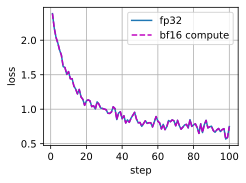

In [11]:
loss32, acc32, sec32 = train(mixed=False)
loss16, acc16, sec16 = train(mixed=True)
print(f'fp32: loss {loss32[-1]:.3f}, val acc {acc32:.3f}, {sec32:.2f}s')
print(f'bf16: loss {loss16[-1]:.3f}, val acc {acc16:.3f}, {sec16:.2f}s')
d2l.plot(list(range(1, 101)), [loss32, loss16], 'step', 'loss',
         legend=['fp32', 'bf16 compute'])

The two curves lie on top of each other and their validation accuracies agree:
16-bit rounding perturbs each step slightly, so the trajectories are not
bitwise identical, but they descend at the same rate to the same place. The
reported time reflects this CPU-sized experiment: bf16
may be no faster, and can be slower when casting overhead dominates. The
wall-clock payoff appears on accelerators with native 16-bit matrix units and
in models large enough to occupy them; speedup depends on hardware, shapes,
and the input pipeline (we turn to GPUs in that section). Activations
still occupy half the memory. Note what mixed
precision does *not* buy: the master weights and any Adam state remain fp32,
so the parameter and optimizer terms in the memory arithmetic of
that section do not shrink. The savings are in activations
and speed.


### Loss Scaling for fp16

With bf16, the recipe above is complete. fp16 has one more failure mode, and
it is the opposite end of the axis from the overflow that opened this section:
*gradient underflow*. Many gradients are small. Below about
$6.10 \times 10^{-5}$ fp16 uses increasingly coarse subnormals, and below
about $5.96 \times 10^{-8}$ values round to zero:

In [12]:
g = jnp.array(1e-8)
g.astype(jnp.float16), (g * 2**16).astype(jnp.float16)

(Array(0., dtype=float16), Array(0.000655, dtype=float16))

The gradient vanishes, yet the same value scaled by $2^{16}$ is perfectly
representable. That is the idea of *loss scaling*: multiply the loss by a
large constant before backpropagation, so that by linearity every gradient is
scaled into representable territory, then divide the gradients by the same
constant before the optimizer step.

optax ships no automatic scaler, and JAX code rarely misses it. The idiom
grew up on TPUs where bf16 is the native 16-bit format, and bf16 needs no
scaling: its normal exponent range matches fp32 and covers the magnitudes
encountered in ordinary training. The recipe of this section,
`dtype=jnp.bfloat16` over fp32
parameters, is therefore already complete, and we deliberately skip fp16 loss
scaling. If old hardware ever forces fp16 on you, the two multiplications are
yours to write: scale the loss inside `loss_fn`, divide the gradients before
`optax.apply_updates`.

## When Numerics Bite

A short field guide for the day training misbehaves.

**The loss is NaN.** NaN is usually a symptom, not the disease; the disease is
`inf`, because `inf` arithmetic breeds NaN:

In [13]:
s = jnp.array(60000., dtype=jnp.float16) * 2  # overflows
s, s - s

(Array(inf, dtype=float16), Array(nan, dtype=float16))

By the time a NaN reaches your loss, the overflow that spawned it may be many
operations upstream, and once a NaN lands in the weights it poisons every
subsequent step. So diagnose in order: first check ranges (is anything in
fp16? are intermediate values in the $10^4$ regime and headed for the 65504
ceiling?), and only then blame the learning rate.

JAX can localize the culprit for you: set
`jax.config.update('jax_debug_nans', True)` and execution stops with an error
at the first operation whose output is NaN, instead of letting it wash
downstream into the loss. The check reruns jitted code operation by
operation when it trips, so treat it as a debugging mode, not a default.

**Let the library take the log.** The naive evaluation of
$\log \sum_i \exp(x_i)$ overflows long before the answer does:

In [14]:
x = jnp.array([12.0, 11.0, 10.0], dtype=jnp.float16)
jnp.log(jnp.exp(x).sum()), jax.scipy.special.logsumexp(x)

(Array(inf, dtype=float16), Array(12.41, dtype=float16))

The answer, 12.4, is unremarkable; only the intermediate $e^{12}$ exceeds
65504. The subtract-the-max shift from that section fixes
it, and the practical form of the lesson is to never hand-roll the pattern.

`jax.scipy.special.logsumexp`, `jax.nn.log_softmax`, and optax's
cross-entropy losses all build the shift in.

**Accumulate in fp32.** Long sums in a 16-bit dtype drift, because once the
running total is large, each small increment falls below the spacing of
representable values and is partly or wholly rounded away:

In [15]:
x = jnp.full((10**7,), 1e-3, dtype=jnp.float16)
x.cumsum()[-1], x.astype(jnp.float32).cumsum()[-1]

(Array(1.001e+04, dtype=float16), Array(10004.044, dtype=float32))

The two totals disagree in the fourth digit. The fp32 accumulation, 10004, is
the exact sum of the stored values (0.001 itself rounds to the nearest fp16,
which is why the answer is not 10000); the fp16 accumulation drifts above it.
The drift is milder than a naive sequential loop would produce, because XLA
evaluates the scan as a tree, which keeps the partial sums small, but it is
drift all the same and it grows with the length of the sum. Means over large
batches, epoch-level loss totals, and variance computations all follow this
pattern, and it is why our training loop cast logits to fp32 before the loss.
When you write your own reduction over 16-bit data, upcast first, as the
second expression does.

Finally, do not expect bitwise equality across
numeric configurations: tf32 versus fp32, or mixed precision on versus off,
differ in the last bits by design. What reproducibility you can demand, and
how to get it, is the subject of that section.

## Summary

A dtype is a contract about range and precision, and the 16-bit formats split
the difference between them: fp16 keeps precision and forfeits range, bf16
keeps fp32's range and forfeits precision, which suits deep learning better.

In flax the storage and compute formats are the two constructor arguments of
every layer: casting a model for inference means bf16 in both (or one
`tree.map` over the parameters), while mixed-precision training sets
`dtype=jnp.bfloat16` and leaves `param_dtype` at fp32, master weights and
16-bit matrix multiplications with no context manager in sight. Train in
bf16; fp16 loss scaling is machinery for older hardware that JAX practice
skips.

When numbers misbehave: check for
overflow before blaming the learning rate, use the library's `logsumexp`
family, and accumulate long sums in fp32.

## Exercises

1. Redo the memory arithmetic of that section for
   mixed-precision training with Adam: fp32 master weights, fp32 gradients,
   two fp32 moment estimates, and bf16 activations. Which term dominates now,
   and how does the total compare with all-fp32 training?
1. Time the fp32 and 16-bit runs of `train` against each other while
   shrinking the hidden width and the batch size. Find a model small enough
   that mixed precision is *slower* than fp32, and explain where the
   crossover comes from.
1. Print every field of `torch.finfo(torch.float8_e4m3fn)` (in JAX,
   `jnp.finfo(jnp.float8_e4m3fn)`; in TensorFlow,
   `ml_dtypes.finfo(ml_dtypes.float8_e4m3fn)`; MXNet has no fp8 dtype, so
   borrow the standalone `ml_dtypes` package) and compare with fp16 and
   bf16. Explain
   the name `e4m3fn`, including why its `max` is 448 rather than the value
   the exponent bits alone would suggest.
1. Under autocast, normalization layers run in fp32. To see why, take the
   `RMSNorm` layer of that section, feed it inputs with a
   standard deviation of about 100, and force the computation to fp16. Which
   intermediate quantity fails first?